# First All-photonic Repeater Network

This example will demonstrate how to use QNPack to simulate a quantum network repeater chain using a single quantum repeater (QR).

<img src="./images/ape_network.png" width="75%"><br>



The APE repeater network is consisted of quantum end nodes (Q-nodes), quantum repeaters (QRs), Bell-State-Measurement nodes (BSM),  classical and quantum channels. In the beginning, the emitter qubit in APE QRs will emit Repeater Graph State (RGS) following a predefined circuit. Since each APE QR generates and transmits RGS photonic qubits sequentially in a predefined manner, each photonic qubit arriving at a BSM-node in the designated time interval can be identified as either a leaf, 1st-level core or 2nd-level core qubit. We make the following assumptions of photon loss and noise:
1. The sources of photon loss include collection efficiency, quantum frequency conversion efficiency, fiber attenuation, and detector efficiency.
2. The only noises are emitter (quantum dot) decoherence in APE QR and memory (nuclear spin) decoherence in Q-nodes.

In the code below, we first demonstrate how to use QNPack to simulate a quantum network repeater chain using a single quantum repeater (QR).


In [ ]:
from qnpack.APE.allphotonic import APESimulation

fixed_params = {
    "network": {"photon_loss": 0},
    "emitter":{"emitter_T2":0, "memory_T2":0,"QFC_loss":0},    
    "rgs":{"num_branches_half":3,"b0":1,"b1":0} 
}
varying_params = {
    "num_repeaters": [1,2,3,4],
    "distance": [10]
}

sim = APESimulation(fixed_params=fixed_params,
                    varying_params=varying_params,
                    iterations=30,
                    min_successful=0,
                    parameter_file="parameters/scenario1.yml",
                    output_dir="results")
data=sim.start()
sim.plot(final_data=data, show_theo_rate=True, x_axis1="num_repeaters", y_axis1="sim_rate", xlabel1="Number of repeaters", ylabel1="Rate (Hz)",
     label_param1="distance", title1="Rate vs Number of repeaters",
     x_axis2="num_repeaters", y_axis2="fidelity", xlabel2="Number of repeaters", ylabel2="Fidelity",
     label_param2="distance", title2="Fidelity vs Number of repeaters"
     )

# Effect of photon loss:
We can see under the ideal situation, the repeater rate is increasing with number of repeaters. The entanglement fidelity of the final Bell pair is perfect too. Next, we introduce photon loss due to fiber attenuation and see how the repeater performance will be affected. The photon loss probability scales exponentially with length of the quantum channel L:
$P_{loss}=10^{-\alpha/L}$ where $\alpha$ is the signal attenuation rate in 0.2dB/km. The following code introduces photon loss in the same repeater setting from above.



In [ ]:
from qnpack.APE.allphotonic import APESimulation

fixed_params = {
    "network": {"photon_loss": 0.2},
    "emitter":{"emitter_T2":0, "memory_T2":0,"QFC_loss":0},
    "rgs":{"num_branches_half":3,"b0":1,"b1":0}    
}
varying_params = {
    "num_repeaters": [1,2,3,4],
    "distance": [10]
}

sim = APESimulation(fixed_params=fixed_params,
                    varying_params=varying_params,
                    iterations=30,
                    min_successful=0,
                    parameter_file="parameters/scenario1.yml",
                    output_dir="results")
data=sim.start()
sim.plot(final_data=data, show_theo_rate=True, x_axis1="num_repeaters", y_axis1="sim_rate", xlabel1="Number of repeaters", ylabel1="Rate (Hz)",
     label_param1="distance", title1="Rate vs Number of repeaters",
     x_axis2="num_repeaters", y_axis2="fidelity", xlabel2="Number of repeaters", ylabel2="Fidelity",
     label_param2="distance", title2="Fidelity vs Number of repeaters"
     )

# Tree-encoded RGS and fault tolerent measurement
We can see that the repeater rate decreases drastically when fiber loss is introduced. This is because we have not introduced an essential component - the encoding that protects against photon loss. In the RGS, each core qubit plays the role of the trapped ion. All the core qubits are fully connected with one another in the graph. This is as if we perform the DBSM of trapped-ion repeater in advance, and perform Bell State measurement between photons emitted by trapped-ion afterwards. But in the APE case, the leaf qubits play the role of those photons emitted by trapped-ions.  
<img src="./images/GS_tree_encoding.png" width="40%"><br>

The RGS scheme requires at least one BSM among m BSM to be successful, and all the core qubits to be successfully measured. The probability for that to happen in one repeater node is

$P_{BSM}=(1-P_{loss})^2/2$

$P_{oneBSM}=1-(1-P_{BSM})^m$

$P_{oneRepeater}=P_{oneBSM}^2*P_{loss}^{2m}$

The requirement of all core qubits to be successfully measured is formiddable without encoding. The code below shows how we can set up the 2-level tree-encoding of RGS, with a total of 12 branches, each consisted of a tree with parameters $b_0=6$ and $b_1=3$. 

Updated network.photon_loss: 0.2 -> 0.2
Updated emitter.emitter_T2: 3000 -> 0
Updated emitter.memory_T2: 20000000.0 -> 0
Updated emitter.QFC_loss: 0.05 -> 0
Updated rgs.num_branches_half: 3 -> 6
Updated rgs.b0: 1 -> 6
Updated rgs.b1: 0 -> 3
self.cfg.network.photon_loss 0.2
16:31:52 qnpack.APE.allphotonic INFO Configuration:
bsm:
  coupling_efficiency: 0.9
  detection_window: 3
  detector_wait_factor: 1.05
  max_emission_retries: 90
  system_delay: 0
  timeout: 40
clock:
  HZ: 1000000
  max_ticks: -1
emitter:
  CZ_duration: 100
  EMIT_PHOTON_duration: 2
  H_duration: 1
  INIT_duration: 1
  MEASURE_duration: 20
  QFC_loss: 0
  collection_eff: 1
  detector_eff: 1
  emitter_T1: 0
  emitter_T2: 0
  mem_measure: forced
  memory_T1: 0
  memory_T2: 0
  photon_emission_buffer: 1
network:
  c_lightspeed: 200000
  channel_depolar_rate: 0
  init_photon_loss: 0
  node_c_pos: 0
  photon_loss: 0.2
  proto_sched: 1
  q_lightspeed: 200000
rgs:
  b0: 6
  b1: 3
  num_branches_half: 6
sim:
  debug: false


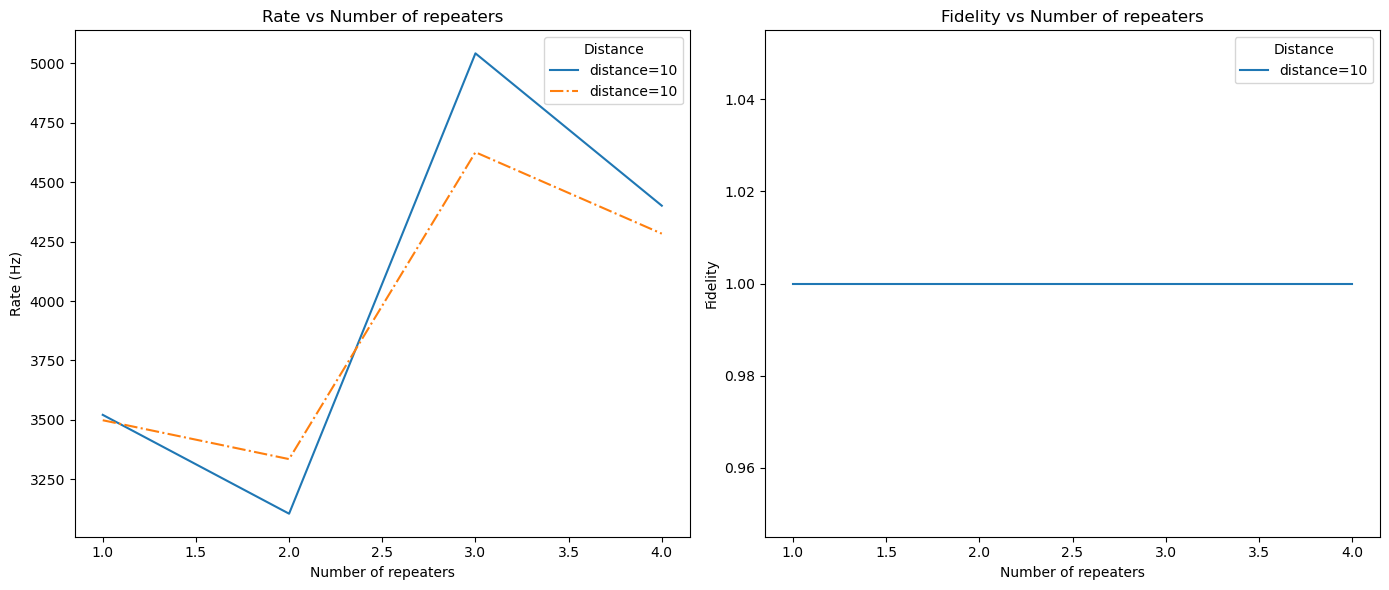

In [1]:
from qnpack.APE.allphotonic import APESimulation

fixed_params = {
    "network": {"photon_loss": 0.2},
    "emitter":{"emitter_T2":0, "memory_T2":0,"QFC_loss":0},    
    "rgs":{"num_branches_half":6,"b0":6,"b1":3}
}
varying_params = {
    "num_repeaters": [1,2,3,4],
    "distance": [10]
}

sim = APESimulation(fixed_params=fixed_params,
                    varying_params=varying_params,
                    iterations=10,
                    min_successful=0,
                    parameter_file="parameters/scenario1.yml",
                    output_dir="results")
data=sim.start()
sim.plot(final_data=data, show_theo_rate=True, x_axis1="num_repeaters", y_axis1="sim_rate", xlabel1="Number of repeaters", ylabel1="Rate (Hz)",
     label_param1="distance", title1="Rate vs Number of repeaters",
     x_axis2="num_repeaters", y_axis2="fidelity", xlabel2="Number of repeaters", ylabel2="Fidelity",
     label_param2="distance", title2="Fidelity vs Number of repeaters"
     )

# Effect of quantum emitter coherence time on fidelity:
The tree-encoding helps protect against photon loss since it encodes each core qubit by a tree which is consisted of multiple photons. However, there are also huge resource overhead for generating such a large entangled photonic state. Inside NetSquid, we simulate the deterministic approach of graph state generation by sequentially stimulating the quantum emitter in each APE QR. The major source of noise comes from the decoherence effect of the quantum emitter during graph state generation. In the code below, we investigate how the docoherence effect impact the fidelity of the final entangled Bell state across the two ends.

Updated network.photon_loss: 0.2 -> 0.2
Updated emitter.emitter_T2: 3000 -> 3000
Updated emitter.memory_T2: 20000000.0 -> 20000000.0
Updated emitter.QFC_loss: 0.05 -> 0
Updated rgs.num_branches_half: 3 -> 6
Updated rgs.b0: 1 -> 6
Updated rgs.b1: 0 -> 3
self.cfg.network.photon_loss 0.2
16:58:16 qnpack.APE.allphotonic INFO Configuration:
bsm:
  coupling_efficiency: 0.9
  detection_window: 3
  detector_wait_factor: 1.05
  max_emission_retries: 90
  system_delay: 0
  timeout: 40
clock:
  HZ: 1000000
  max_ticks: -1
emitter:
  CZ_duration: 100
  EMIT_PHOTON_duration: 2
  H_duration: 1
  INIT_duration: 1
  MEASURE_duration: 20
  QFC_loss: 0
  collection_eff: 1
  detector_eff: 1
  emitter_T1: 0
  emitter_T2: 3000
  mem_measure: forced
  memory_T1: 0
  memory_T2: 20000000.0
  photon_emission_buffer: 1
network:
  c_lightspeed: 200000
  channel_depolar_rate: 0
  init_photon_loss: 0
  node_c_pos: 0
  photon_loss: 0.2
  proto_sched: 1
  q_lightspeed: 200000
rgs:
  b0: 6
  b1: 3
  num_branches_half

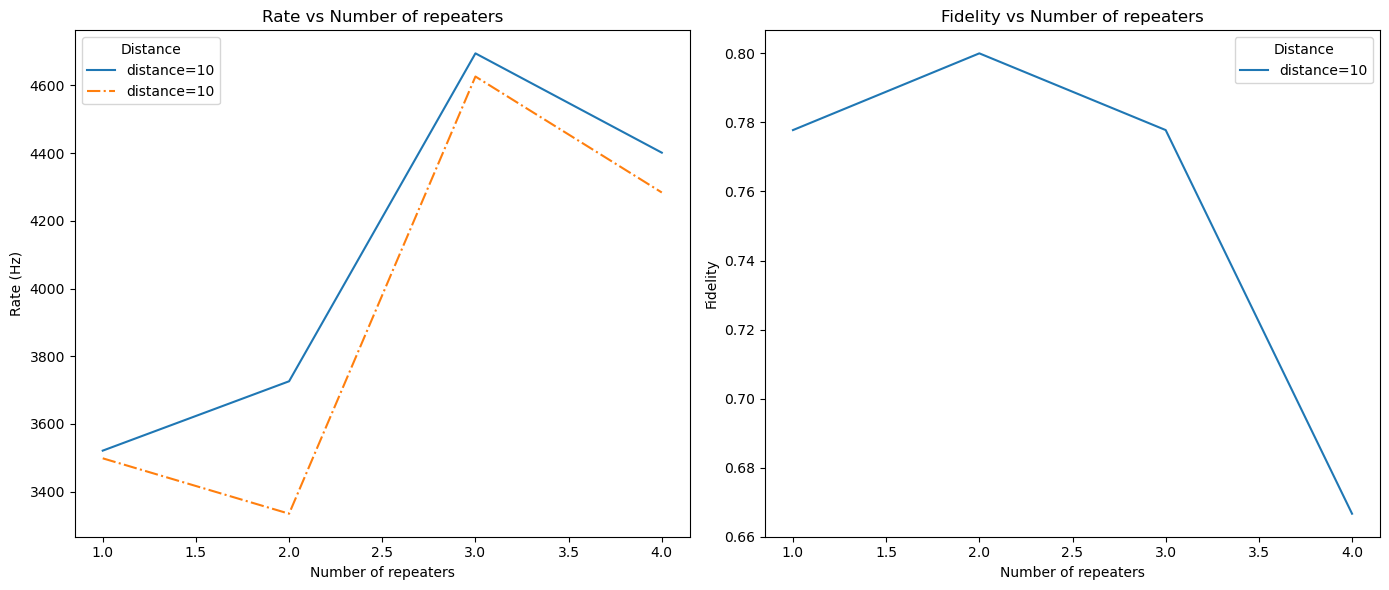

In [2]:
from qnpack.APE.allphotonic import APESimulation

fixed_params = {
    "network": {"photon_loss": 0.2},
    "emitter":{"emitter_T2":3000, "memory_T2":20e+06,"QFC_loss":0},    
    "rgs":{"num_branches_half":6,"b0":6,"b1":3}
}
varying_params = {
    "num_repeaters": [1,2,3,4],
    "distance": [10]
}

sim = APESimulation(fixed_params=fixed_params,
                    varying_params=varying_params,
                    iterations=10,
                    min_successful=0,
                    parameter_file="parameters/scenario1.yml",
                    output_dir="results")
data=sim.start()
sim.plot(final_data=data, show_theo_rate=True, x_axis1="num_repeaters", y_axis1="sim_rate", xlabel1="Number of repeaters", ylabel1="Rate (Hz)",
     label_param1="distance", title1="Rate vs Number of repeaters",
     x_axis2="num_repeaters", y_axis2="fidelity", xlabel2="Number of repeaters", ylabel2="Fidelity",
     label_param2="distance", title2="Fidelity vs Number of repeaters"
     )

Exercise: 
Under the given quantum repeater network configuration, find the optimal rgs size among the given parameters:

| m | $b_0$ | $b_1$ |
|---|---|---|
| 1 | 25 | 1 |
| 5 | 4 | 2 |
| 7 | 8 | 4 |

Task:
For each of the rgs parameters, compute the rate and fidelity and see which gives the best value.

In [ ]:
from qnpack.APE.allphotonic import APESimulation

fixed_params = {
    "network": {"photon_loss": 0.2},
    "emitter":{"emitter_T2":3000, "memory_T2":20e+06,"QFC_loss":0},    
    #Fill in the rgs parameters that you want to calculate here
}
varying_params = {
    "num_repeaters": [1,2,3,4],
    "distance": [10]
}

sim = APESimulation(fixed_params=fixed_params,
                    varying_params=varying_params,
                    iterations=10,
                    min_successful=0,
                    parameter_file="parameters/scenario1.yml",
                    output_dir="results")
data=sim.start()
sim.plot(final_data=data, show_theo_rate=True, x_axis1="num_repeaters", y_axis1="sim_rate", xlabel1="Number of repeaters", ylabel1="Rate (Hz)",
     label_param1="distance", title1="Rate vs Number of repeaters",
     x_axis2="num_repeaters", y_axis2="fidelity", xlabel2="Number of repeaters", ylabel2="Fidelity",
     label_param2="distance", title2="Fidelity vs Number of repeaters"
     )